In [1]:
import pandas as pd
import os
# change directory one up 
os.chdir('..')

In [123]:
# list all files in results/test_varying
files = os.listdir('results/test_single_varying/data=Custom_dataset,experiment=test_single_varying,logging_policy_ranker=linear,policy_strength=1,policy_temperature=0,random_state=2021,relevance=linear,relevance_tower=linear')


def load_and_concat_shift_files(folder_path, prefix, column_name, pos=-1):
    """
    Load CSV files from folder_path that start with prefix, sort them based on the number
    at the end of the filename, add a column with that number, and concatenate all into a single DataFrame.
    
    Args:
        folder_path (str): Path to the folder containing the CSV files.
        prefix (str): Prefix of the files to include.
        column_name (str): Name of the new column to store the shift number.
        idx (int): Index of the parameter to shift (default: -1 for last parameter).

    Returns:
        pd.DataFrame: Concatenated DataFrame of all relevant CSVs with shift column added.
    """
    files = os.listdir(folder_path)
    shift_files = [f for f in files if f.startswith(prefix)]
    # sort files by the number at the end
    shift_files = sorted(shift_files, key=lambda x: float(x.split('_')[pos].replace('.csv','')))
    for idx, f in enumerate(shift_files):
        df = pd.read_csv(os.path.join(folder_path, f))
        df[column_name] = float(f.split('_')[-1].replace('.csv',''))
        if idx == 0:
            combined_df = df
        else:
            combined_df = pd.concat([combined_df, df])
    
    return combined_df


folder_path = 'results/test_varying/data=Custom_dataset,experiment=test_varying,logging_policy_ranker=linear,policy_strength=1,policy_temperature=0,random_state=2021,relevance=linear,relevance_tower=linear'

multi_relevance_df = load_and_concat_shift_files(folder_path, 'relevance_param_shift', 'relevance_param_shift')
multi_performance_df = load_and_concat_shift_files(folder_path, 'test_clicks_param_shift', 'test_clicks_param_shift')

FileNotFoundError: [Errno 2] No such file or directory: 'results/test_single_varying/data=Custom_dataset,experiment=test_single_varying,logging_policy_ranker=linear,policy_strength=1,policy_temperature=0,random_state=2021,relevance=linear,relevance_tower=linear'

In [124]:
multi_relevance_df.relevance_param_shift.unique()

AttributeError: 'DataFrame' object has no attribute 'relevance_param_shift'

In [136]:
import matplotlib.pyplot as plt

# Step 1: get relevance values at shift 0
baseline = multi_relevance_df[multi_relevance_df['relevance_param_shift'] == 0]['relevance'].reset_index(drop=True)

# Step 2: create an empty DataFrame to store differences
diff_df = pd.DataFrame()

# Step 3: compute difference for each shift
for shift in multi_relevance_df['relevance_param_shift'].unique():
    values = multi_relevance_df[multi_relevance_df['relevance_param_shift'] == shift]['relevance'].reset_index(drop=True)
    diff_df[shift] = values - baseline  # element-wise difference

# Step 4: plot boxplot of differences
plt.figure(figsize=(12, 6))
diff_df.boxplot(grid=True)

plt.xlabel('Relevance Parameter Shift')
plt.ylabel('Difference in Relevance Compared to Shift 0')
plt.title('Distribution of Element-wise Differences Across Parameter Shifts')
plt.show()

KeyError: 'relevance_param_shift'

In [137]:
multi_performance_df

,nll,loss,relevance_shift,param_idx
0,0.461006,0.461006,-3.0,0
0,0.427060,0.427060,-2.0,0
0,0.404675,0.404675,-1.0,0
0,0.397247,0.397247,0.0,0
0,0.405452,0.405452,1.0,0
...,...,...,...,...
0,0.399772,0.399772,-1.0,9
0,0.397247,0.397247,0.0,9
0,0.400567,0.400567,1.0,9
0,0.411281,0.411281,2.0,9


In [138]:
# sort by the shift parameter
multi_performance_df = multi_performance_df.sort_values('test_clicks_param_shift')

plt.figure(figsize=(8,5))

# plot NLL
plt.plot(multi_performance_df['test_clicks_param_shift'], 
         multi_performance_df['nll'], 
         marker='o', label='NLL')

# plot Loss
plt.plot(multi_performance_df['test_clicks_param_shift'], 
         multi_performance_df['loss'], 
         marker='o', label='Loss')

plt.xlabel('Test Clicks Param Shift')
plt.ylabel('Value')
plt.title('NLL and Loss vs Test Clicks Param Shift')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


KeyError: 'test_clicks_param_shift'

In [172]:


def load_and_concat_multi_shift_files(folder_path, prefix, column_name_relevance, column_name_idx):
    files = os.listdir(folder_path)
    shift_files = [f for f in files if f.startswith(prefix)]
    print(shift_files)
    # sort files by the number at the end
    shift_files = sorted(shift_files, key=lambda x: float(x.split('_')[-2].replace('.csv','')))
    shift_files = sorted(shift_files, key=lambda x: float(x.split('idx')[-1].replace('.csv','')))
    for idx, f in enumerate(shift_files):
        df = pd.read_csv(os.path.join(folder_path, f))
        df[column_name_relevance] = float(f.split('_')[-2].replace('.csv',''))
        df[column_name_idx] = int(f.split('idx')[-1].replace('.csv',''))
        if idx == 0:
            combined_df = df
        else:
            combined_df = pd.concat([combined_df, df])
    return combined_df


folder_path_tmp_0 = 'results/test_single_varying/data=Custom_dataset,experiment=test_single_varying,logging_policy_ranker=linear,policy_strength=1,policy_temperature=0.0,random_state=2021,relevance=linear,relevance_tower=linear'
folder_path_tmp_0333 = 'results/test_single_varying/data=Custom_dataset,experiment=test_single_varying,logging_policy_ranker=linear,policy_strength=1,policy_temperature=0.333,random_state=2021,relevance=linear,relevance_tower=linear'
folder_path_tmp_0667 = 'results/test_single_varying/data=Custom_dataset,experiment=test_single_varying,logging_policy_ranker=linear,policy_strength=1,policy_temperature=0.667,random_state=2021,relevance=linear,relevance_tower=linear'
folder_path_tmp_1 = 'results/test_single_varying/data=Custom_dataset,experiment=test_single_varying,logging_policy_ranker=linear,policy_strength=1,policy_temperature=1.0,random_state=2021,relevance=linear,relevance_tower=linear'
folder_path_gumbel_0333 = 'results/test_single_varying/data=Custom_dataset,experiment=test_single_varying,logging_policy_ranker=linear,logging_policy_sampler=gumbel,policy_strength=1,policy_temperature=0.333,random_state=2021,relevance=linear,relevance_tower=linear'
folder_path_gumbel_0667 = 'results/test_single_varying/data=Custom_dataset,experiment=test_single_varying,logging_policy_ranker=linear,logging_policy_sampler=gumbel,policy_strength=1,policy_temperature=0.667,random_state=2021,relevance=linear,relevance_tower=linear'
folder_path_gumbel_1 = 'results/test_single_varying/data=Custom_dataset,experiment=test_single_varying,logging_policy_ranker=linear,logging_policy_sampler=gumbel,policy_strength=1,policy_temperature=1.0,random_state=2021,relevance=linear,relevance_tower=linear'

prefix = 'relevance_param_shift_'

multi_relevance_df_tmp_0 = load_and_concat_multi_shift_files(folder_path_tmp_0, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_tmp_0333 = load_and_concat_multi_shift_files(folder_path_tmp_0333, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_tmp_0667 = load_and_concat_multi_shift_files(folder_path_tmp_0667, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_tmp_1 = load_and_concat_multi_shift_files(folder_path_tmp_1, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_gumbel_0333 = load_and_concat_multi_shift_files(folder_path_gumbel_0333, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_gumbel_0667 = load_and_concat_multi_shift_files(folder_path_gumbel_0667, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_gumbel_1 = load_and_concat_multi_shift_files(folder_path_gumbel_1, prefix, 'relevance_shift', 'param_idx')



['relevance_param_shift_1.0_idx7.csv', 'relevance_param_shift_-3.0_idx7.csv', 'relevance_param_shift_2.0_idx9.csv', 'relevance_param_shift_2.0_idx8.csv', 'relevance_param_shift_-3.0_idx6.csv', 'relevance_param_shift_1.0_idx6.csv', 'relevance_param_shift_1.0_idx4.csv', 'relevance_param_shift_-3.0_idx4.csv', 'relevance_param_shift_-3.0_idx5.csv', 'relevance_param_shift_1.0_idx5.csv', 'relevance_param_shift_1.0_idx1.csv', 'relevance_param_shift_-3.0_idx1.csv', 'relevance_param_shift_-3.0_idx0.csv', 'relevance_param_shift_1.0_idx0.csv', 'relevance_param_shift_1.0_idx2.csv', 'relevance_param_shift_-3.0_idx2.csv', 'relevance_param_shift_-3.0_idx3.csv', 'relevance_param_shift_1.0_idx3.csv', 'relevance_param_shift_0.0_idx8.csv', 'relevance_param_shift_-2.0_idx8.csv', 'relevance_param_shift_-1.0_idx6.csv', 'relevance_param_shift_3.0_idx6.csv', 'relevance_param_shift_3.0_idx7.csv', 'relevance_param_shift_-1.0_idx7.csv', 'relevance_param_shift_-2.0_idx9.csv', 'relevance_param_shift_0.0_idx9.csv',

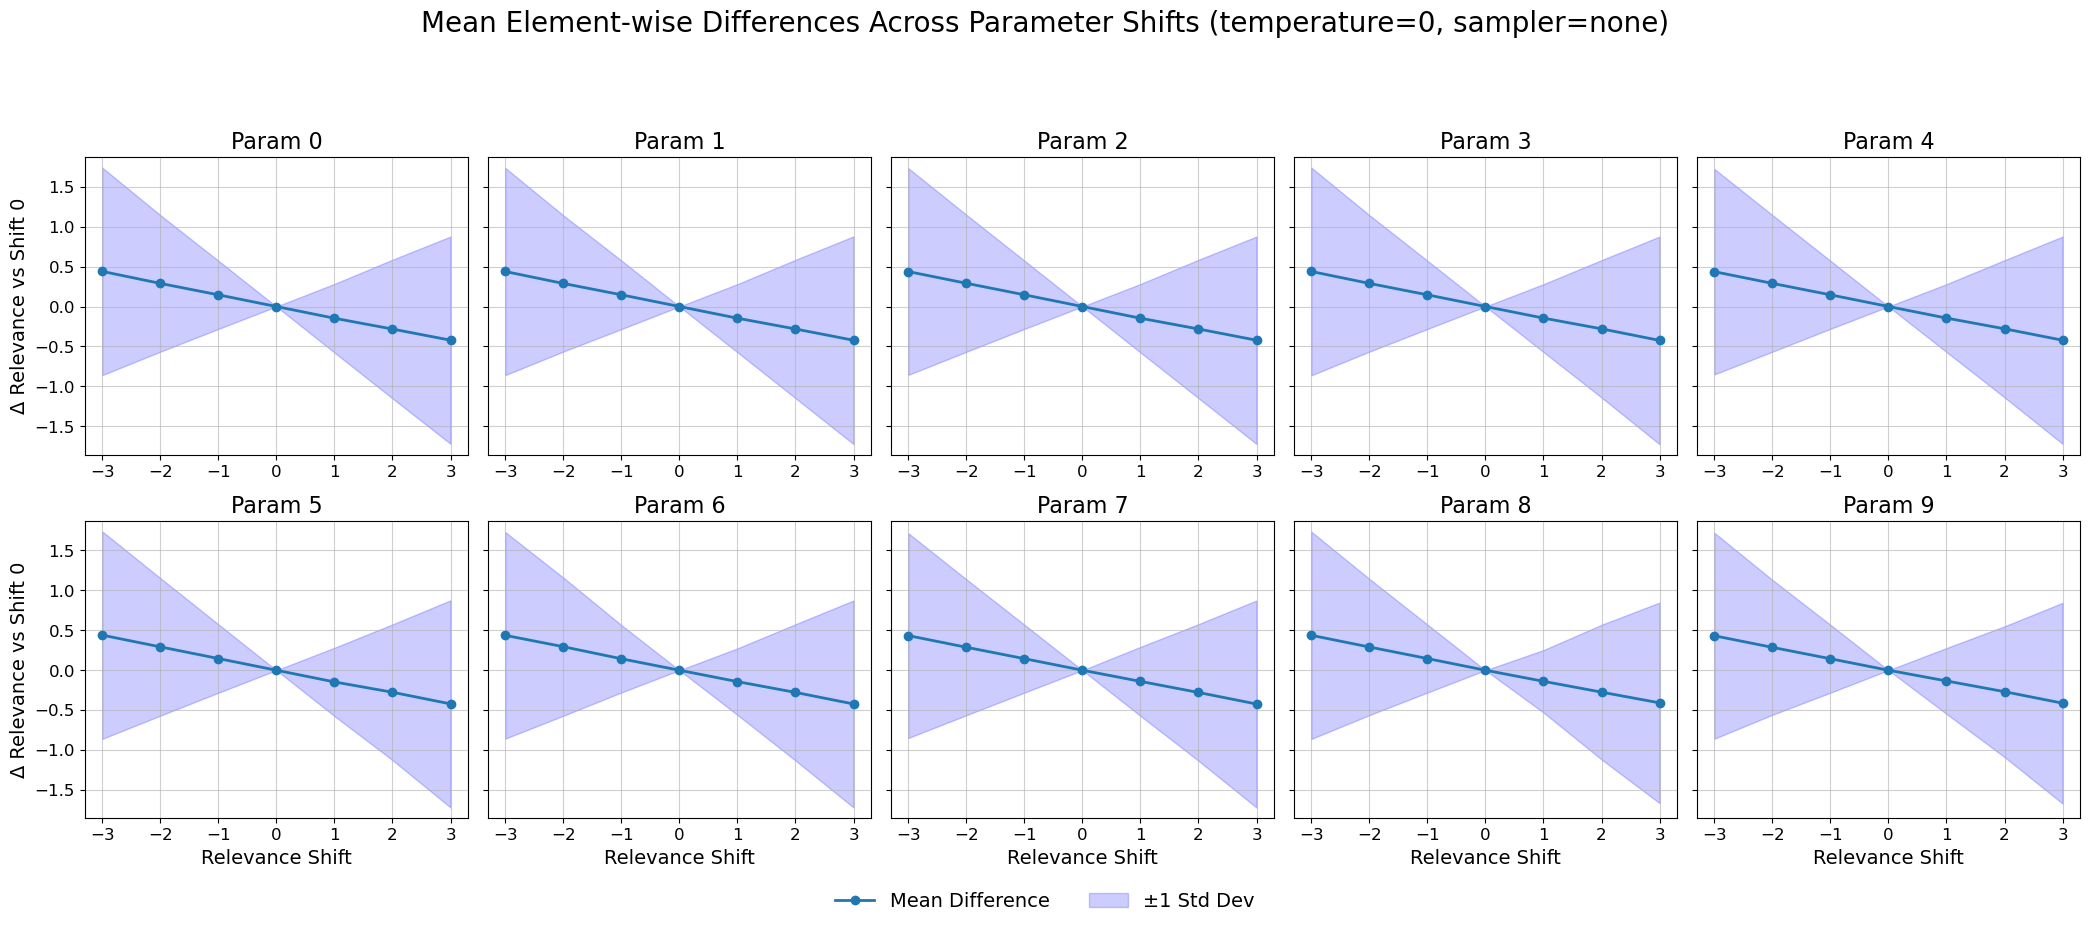

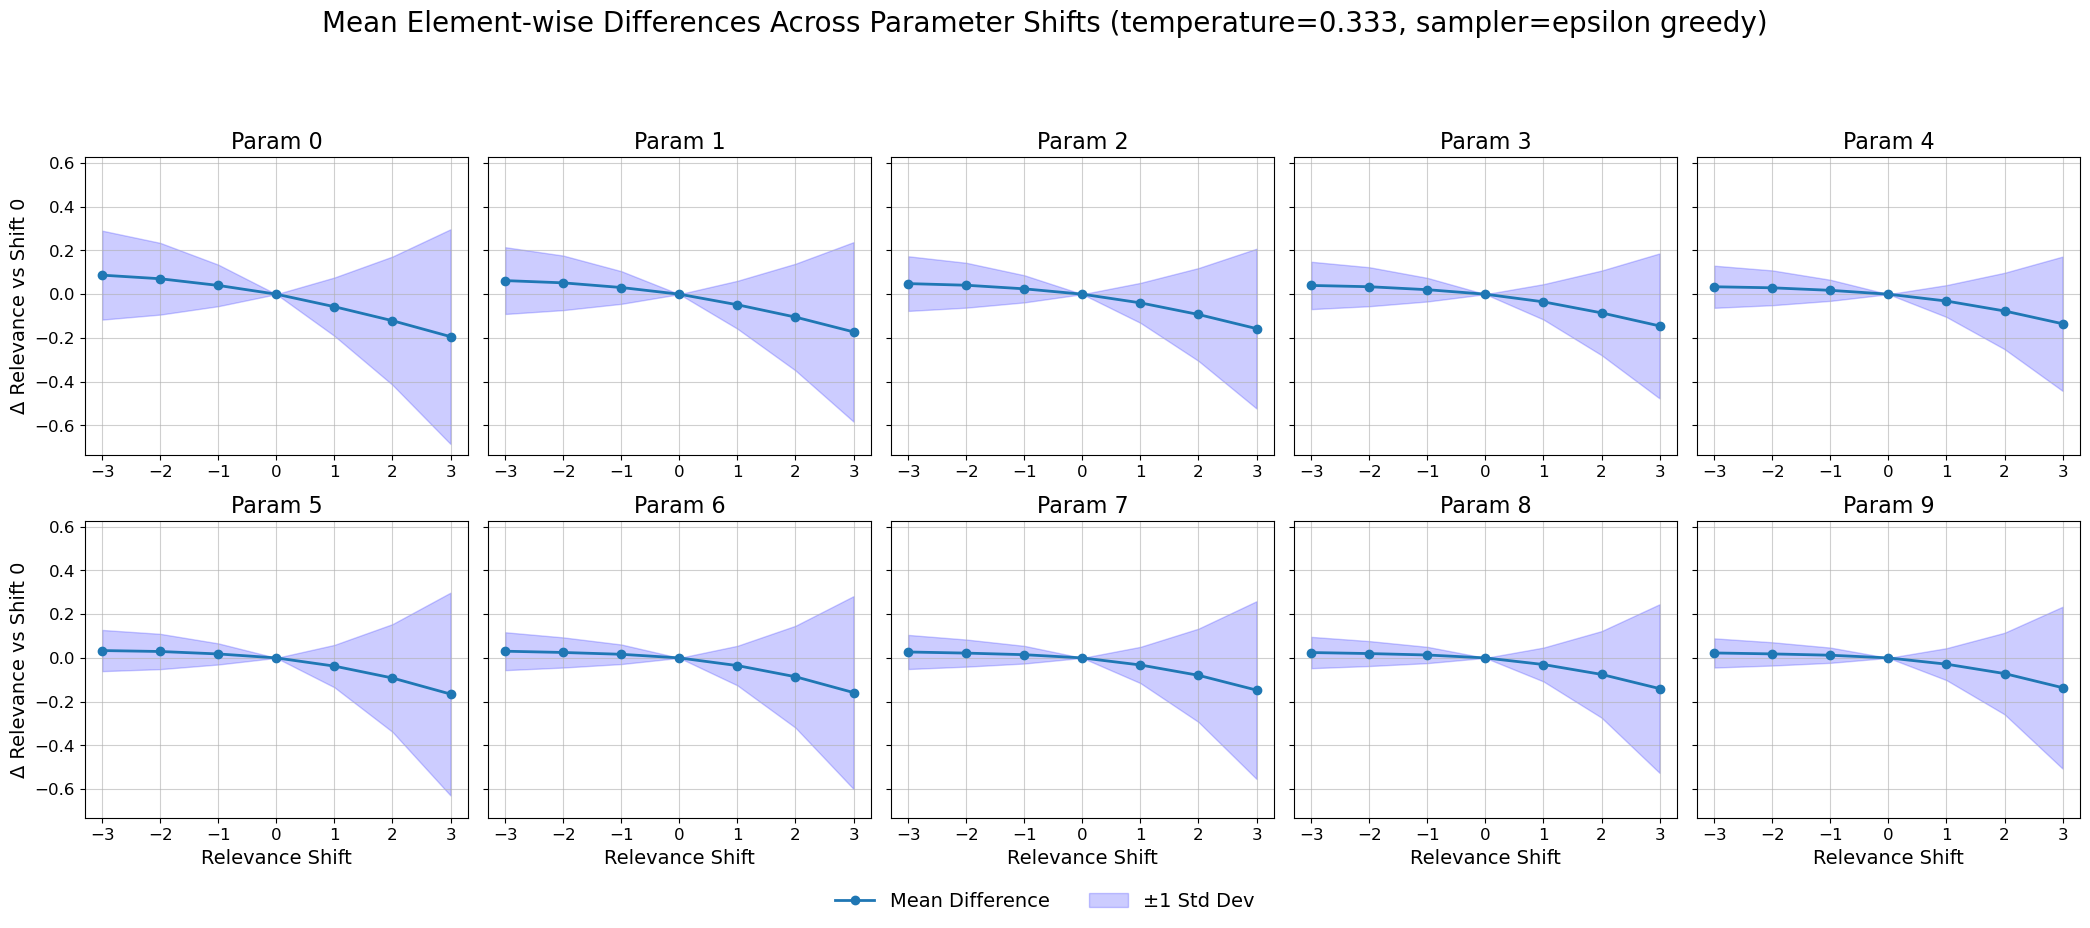

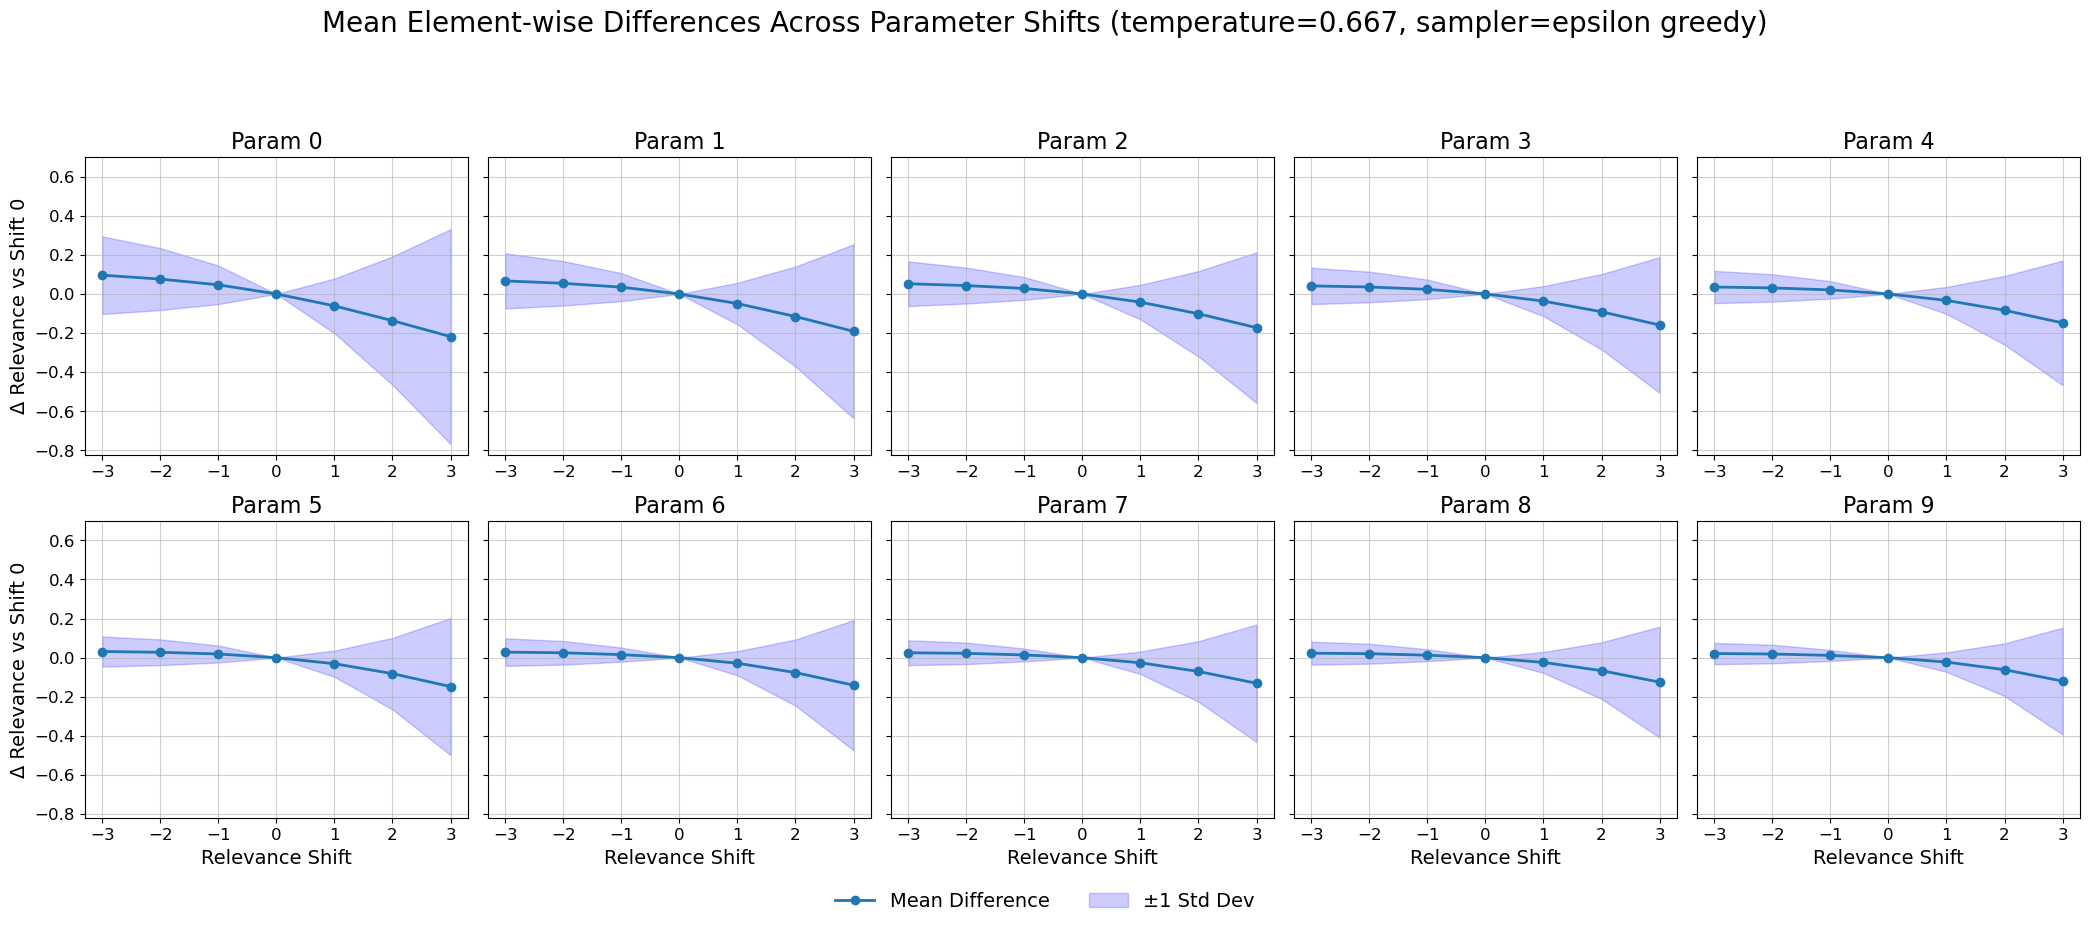

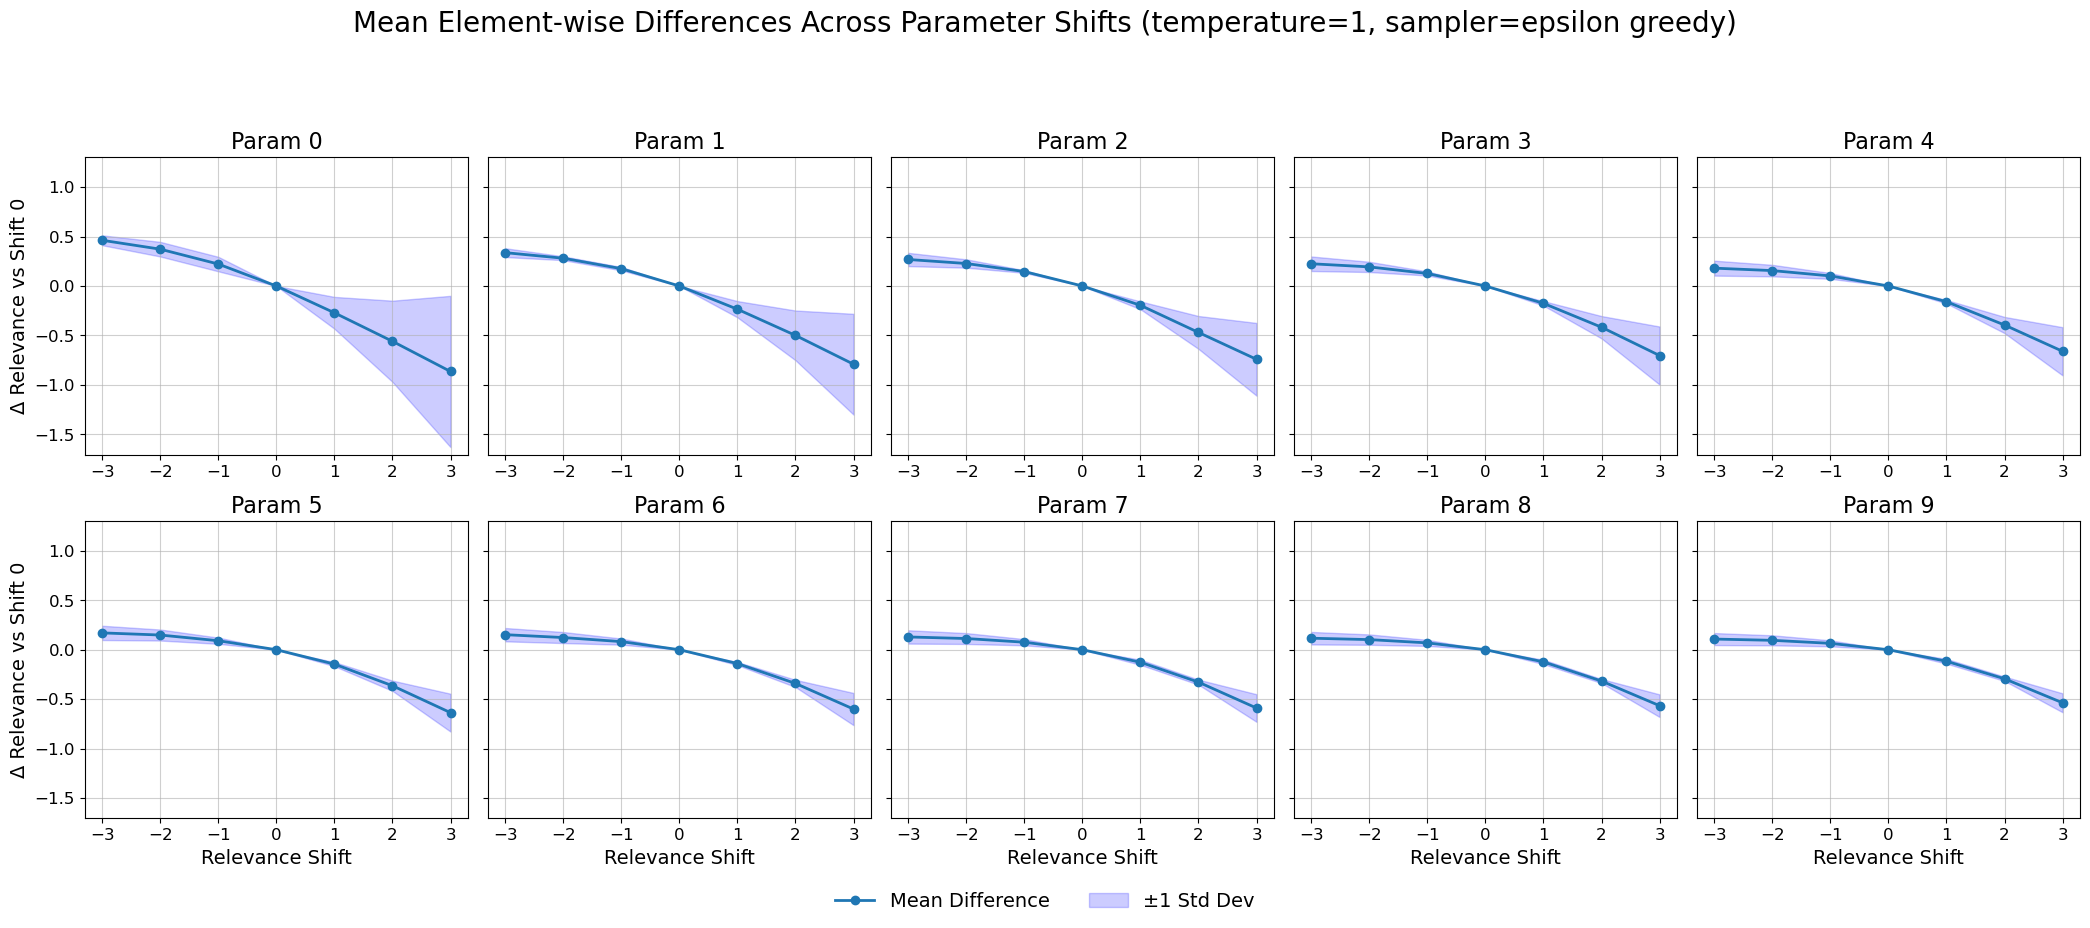

In [177]:
# plot the relevance shift for each param idx, taking the mean shift of relevance compared to shift 0
import matplotlib.pyplot as plt
def plot_mean_relevance_shift_box(multi_relevance_df, temperature):
    for idx in range(10):
        subset = multi_relevance_df[multi_relevance_df['param_idx'] == idx]
        baseline = subset[subset['relevance_shift'] == 0]['relevance'].reset_index(drop=True)
        
        diff_df = pd.DataFrame()
        for shift in subset['relevance_shift'].unique():
            values = subset[subset['relevance_shift'] == shift]['relevance'].reset_index(drop=True)
            diff_df[shift] = values - baseline  # element-wise difference
        
        plt.figure(figsize=(12, 6))
        diff_df.boxplot(grid=True)
        
        plt.xlabel('Relevance Parameter Shift')
        plt.ylabel('Difference in Relevance Compared to Shift 0')
        plt.title(f'Distribution of Element-wise Differences Across Parameter Shifts for Param Index {idx} and temperature {temperature}')
        plt.show()

# plot the plot as a line plot instead of boxplot, showing mean and std
def plot_mean_relevance_shift_grid(multi_relevance_df, temperature, sampler):
    fig, axes = plt.subplots(2, 5, figsize=(21, 9), sharey=True)
    axes = axes.flatten()

    all_means = []
    all_stds = []

    for idx in range(10):
        ax = axes[idx]
        subset = multi_relevance_df[multi_relevance_df['param_idx'] == idx]
        baseline = subset[subset['relevance_shift'] == 0]['relevance'].reset_index(drop=True)
        
        diff_df = pd.DataFrame()
        for shift in subset['relevance_shift'].unique():
            values = subset[subset['relevance_shift'] == shift]['relevance'].reset_index(drop=True)
            diff_df[shift] = values - baseline  # element-wise difference
        
        means = diff_df.mean()
        stds = diff_df.std()
        
        all_means.extend(means.values)
        all_stds.extend(stds.values)

        ax.plot(means.index, means.values, marker='o', label='Mean Difference', linewidth=2)
        ax.fill_between(means.index, means - stds, means + stds, 
                        color='b', alpha=0.2, label='±1 Std Dev')
        
        ax.set_title(f'Param {idx}', fontsize=16)
        ax.tick_params(axis='both', labelsize=12)
        ax.grid(True, alpha=0.6)

        if idx % 5 == 0:
            ax.set_ylabel('Δ Relevance vs Shift 0', fontsize=14)
        if idx >= 5:
            ax.set_xlabel('Relevance Shift', fontsize=14)

    # Adjust y-limits globally (zoom in with 10% margin)
    ymin = min(all_means) - max(all_stds) * 1.1
    ymax = max(all_means) + max(all_stds) * 1.1
    for ax in axes:
        ax.set_ylim(ymin, ymax)

    # Global title
    fig.suptitle(f'Mean Element-wise Differences Across Parameter Shifts (temperature={temperature}, sampler={sampler})',
                 fontsize=20, y=1.02)

    # Put legend below all subplots
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', fontsize=14, ncol=2, frameon=False)

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

plot_mean_relevance_shift_grid(multi_relevance_df_tmp_0, 0, 'none')
plot_mean_relevance_shift_grid(multi_relevance_df_tmp_0333, 0.333, 'epsilon greedy')
plot_mean_relevance_shift_grid(multi_relevance_df_tmp_0667, 0.667, 'epsilon greedy')
plot_mean_relevance_shift_grid(multi_relevance_df_tmp_1, 1, 'epsilon greedy')


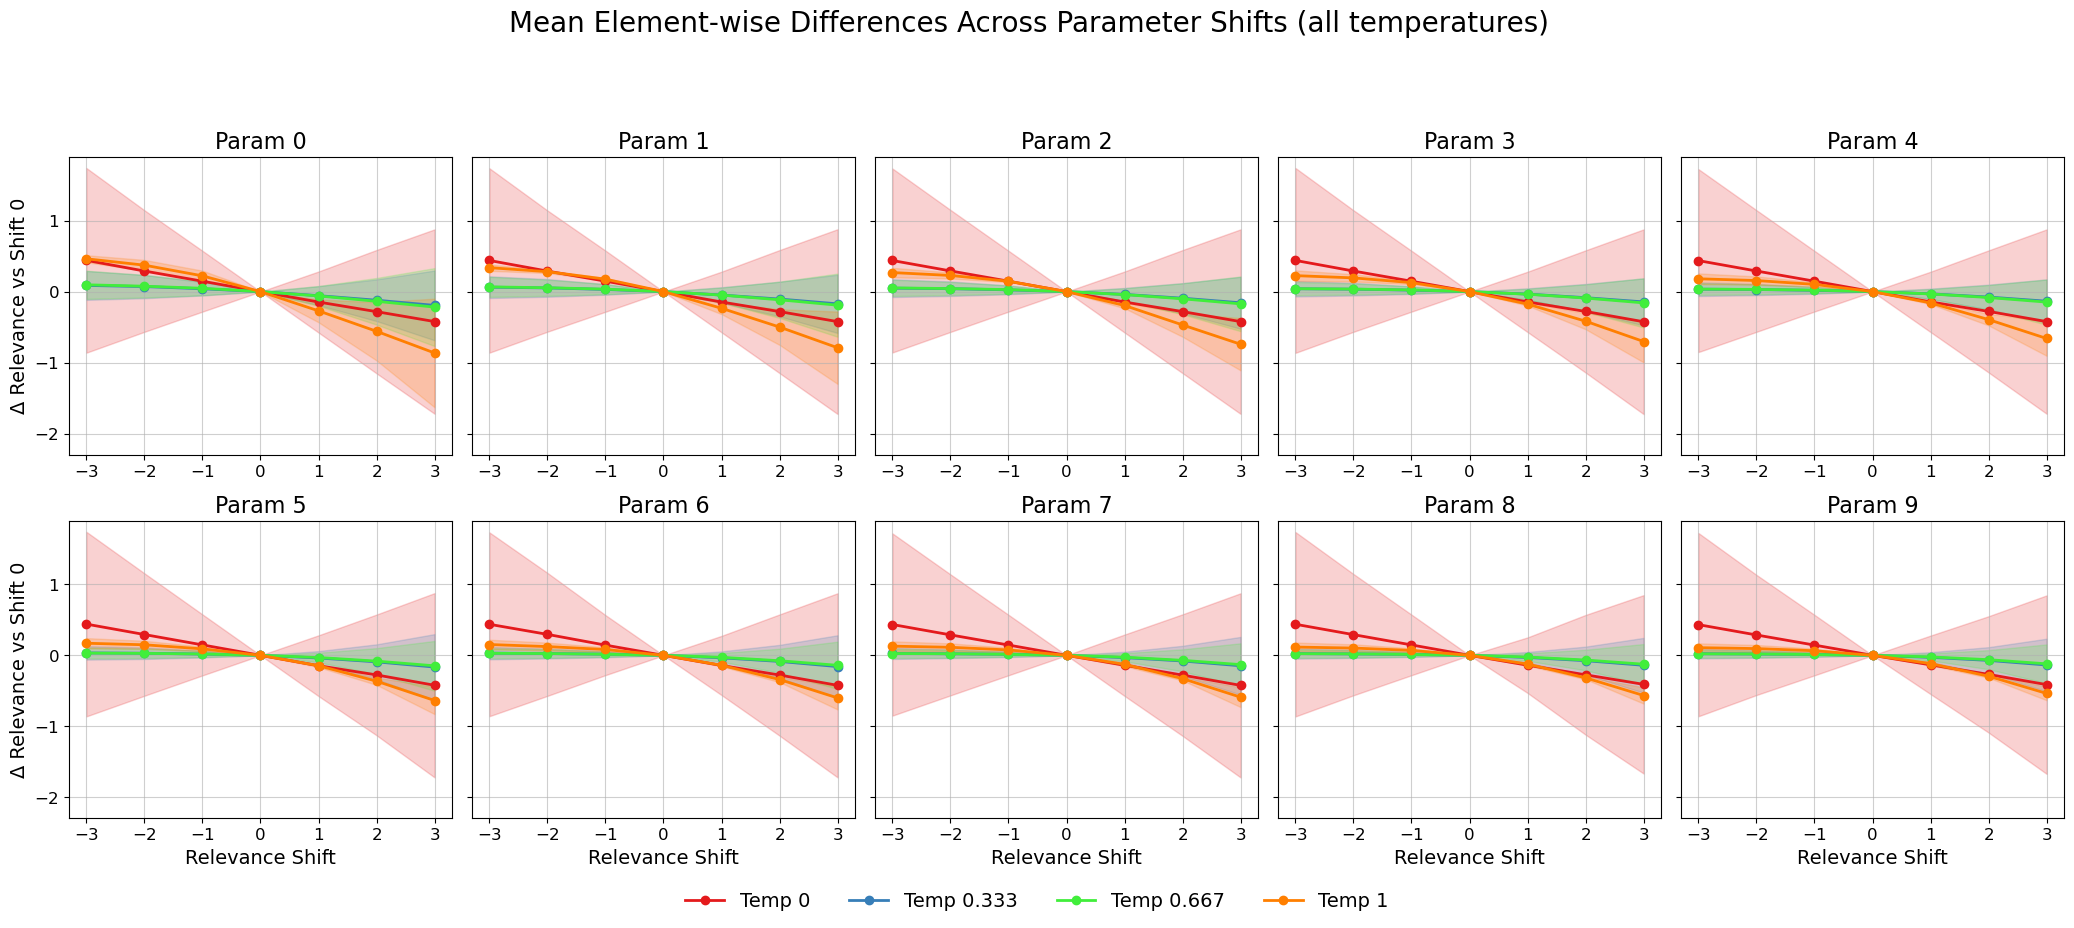

In [204]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_mean_relevance_shift_all(multi_relevance_dfs, temperatures):
    fig, axes = plt.subplots(2, 5, figsize=(21, 9), sharey=True)
    axes = axes.flatten()

    # Highly distinctive colors
    colors = ['#e41a1c', '#377eb8', "#41ee3b", '#ff7f00']  # red, blue, green, orange
    all_means, all_stds = [], []

    for idx in range(10):
        ax = axes[idx]

        # First plot all fill_between in order of temperatures (for layering)
        for df, temp, color in zip(multi_relevance_dfs, temperatures, colors):
            subset = df[df['param_idx'] == idx]
            baseline = subset[subset['relevance_shift'] == 0]['relevance'].reset_index(drop=True)

            diff_df = pd.DataFrame()
            for shift in sorted(subset['relevance_shift'].unique()):
                values = subset[subset['relevance_shift'] == shift]['relevance'].reset_index(drop=True)
                diff_df[shift] = values - baseline

            means = diff_df.mean()
            stds = diff_df.std()

            ax.fill_between(means.index, means - stds, means + stds,
                            color=color, alpha=0.2, zorder=1)  # lower zorder for fills

            all_means.extend(means.values)
            all_stds.extend(stds.values)

        # Then plot the lines on top
        for df, temp, color in zip(multi_relevance_dfs, temperatures, colors):
            subset = df[df['param_idx'] == idx]
            baseline = subset[subset['relevance_shift'] == 0]['relevance'].reset_index(drop=True)

            diff_df = pd.DataFrame()
            for shift in sorted(subset['relevance_shift'].unique()):
                values = subset[subset['relevance_shift'] == shift]['relevance'].reset_index(drop=True)
                diff_df[shift] = values - baseline

            means = diff_df.mean()

            ax.plot(means.index, means.values, marker='o', linewidth=2, 
                    label=f'Temp {temp}', color=color, zorder=2)  # higher zorder for lines

        ax.set_title(f'Param {idx}', fontsize=16)
        ax.tick_params(axis='both', labelsize=12)
        ax.grid(True, alpha=0.6)

        if idx % 5 == 0:
            ax.set_ylabel('Δ Relevance vs Shift 0', fontsize=14)
        if idx >= 5:
            ax.set_xlabel('Relevance Shift', fontsize=14)

    # Global y-limits
    ymin = min(all_means) - max(all_stds) * 1.1
    ymax = max(all_means) + max(all_stds) * 1.1
    for ax in axes:
        ax.set_ylim(ymin, ymax)

    # Global title
    fig.suptitle('Mean Element-wise Differences Across Parameter Shifts (all temperatures)',
                 fontsize=20, y=1.02)

    # Legend below
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', fontsize=14, ncol=4, frameon=False)

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

# Example call
plot_mean_relevance_shift_all(
    [multi_relevance_df_tmp_0, multi_relevance_df_tmp_0333, multi_relevance_df_tmp_0667, multi_relevance_df_tmp_1],
    [0, 0.333, 0.667, 1]
)

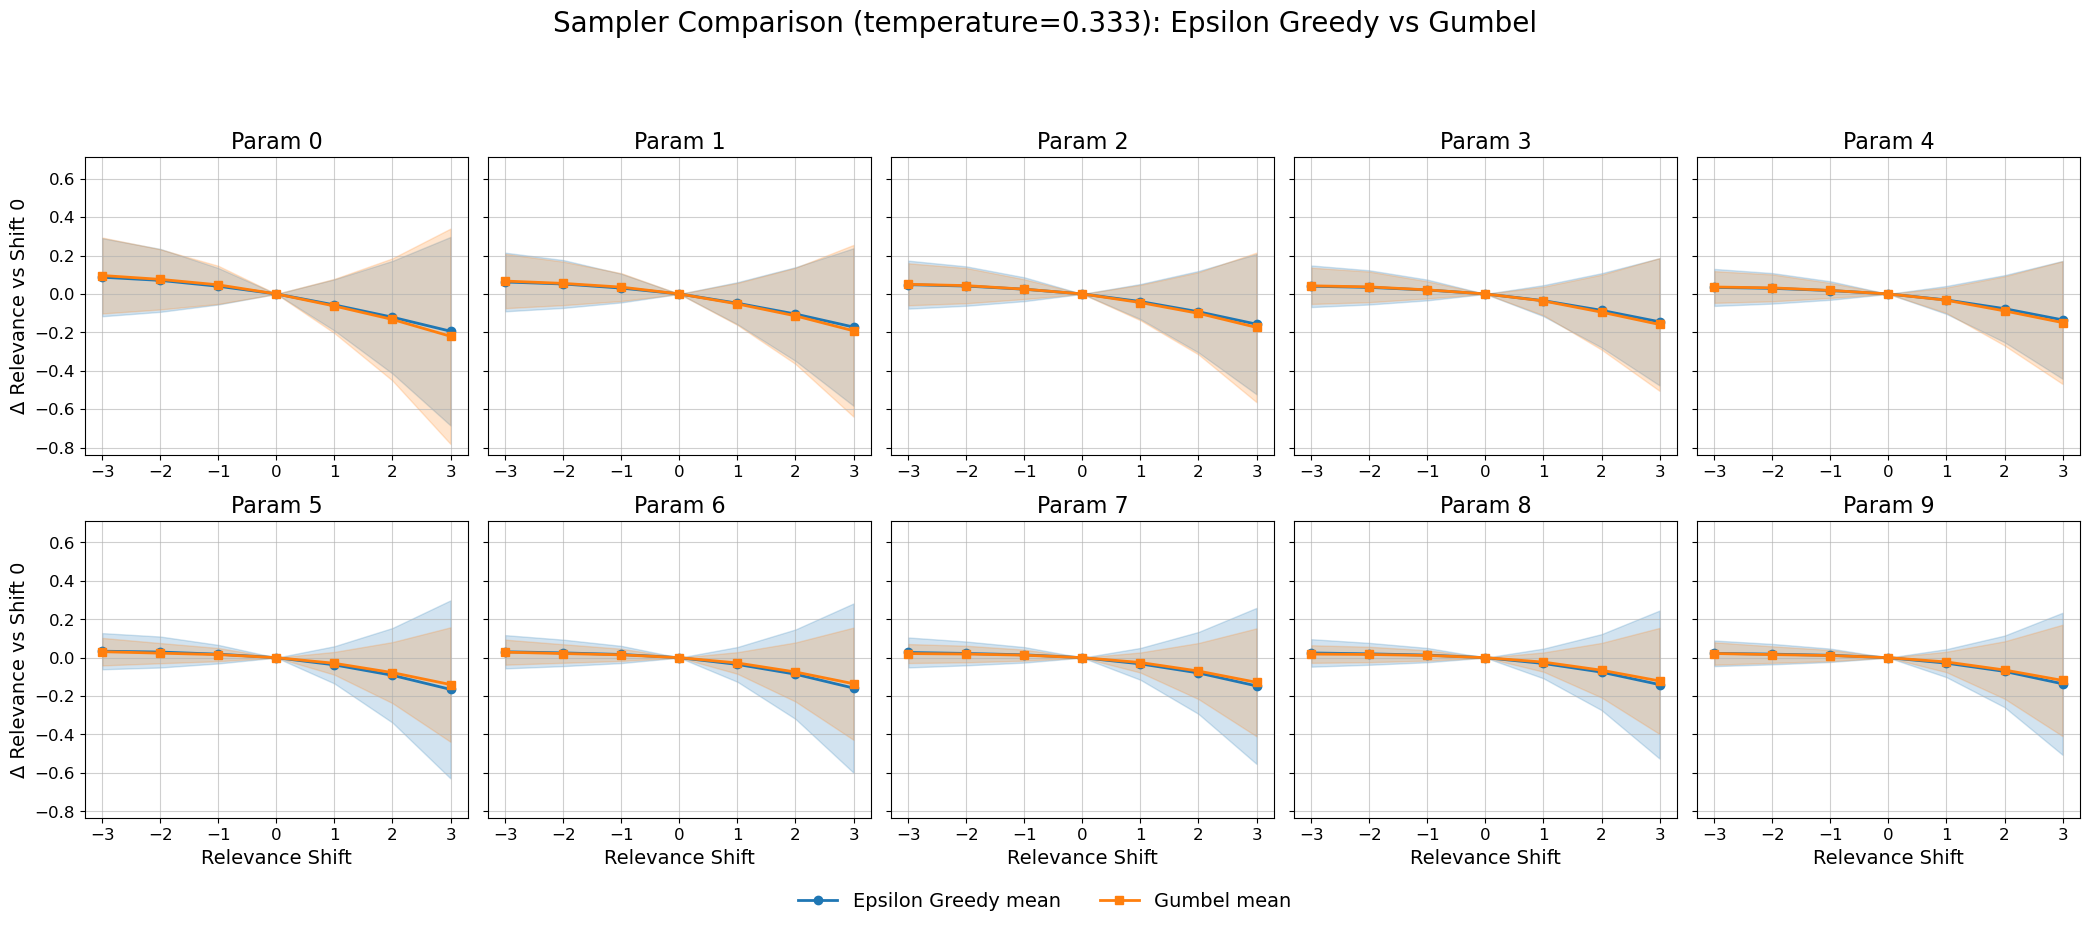

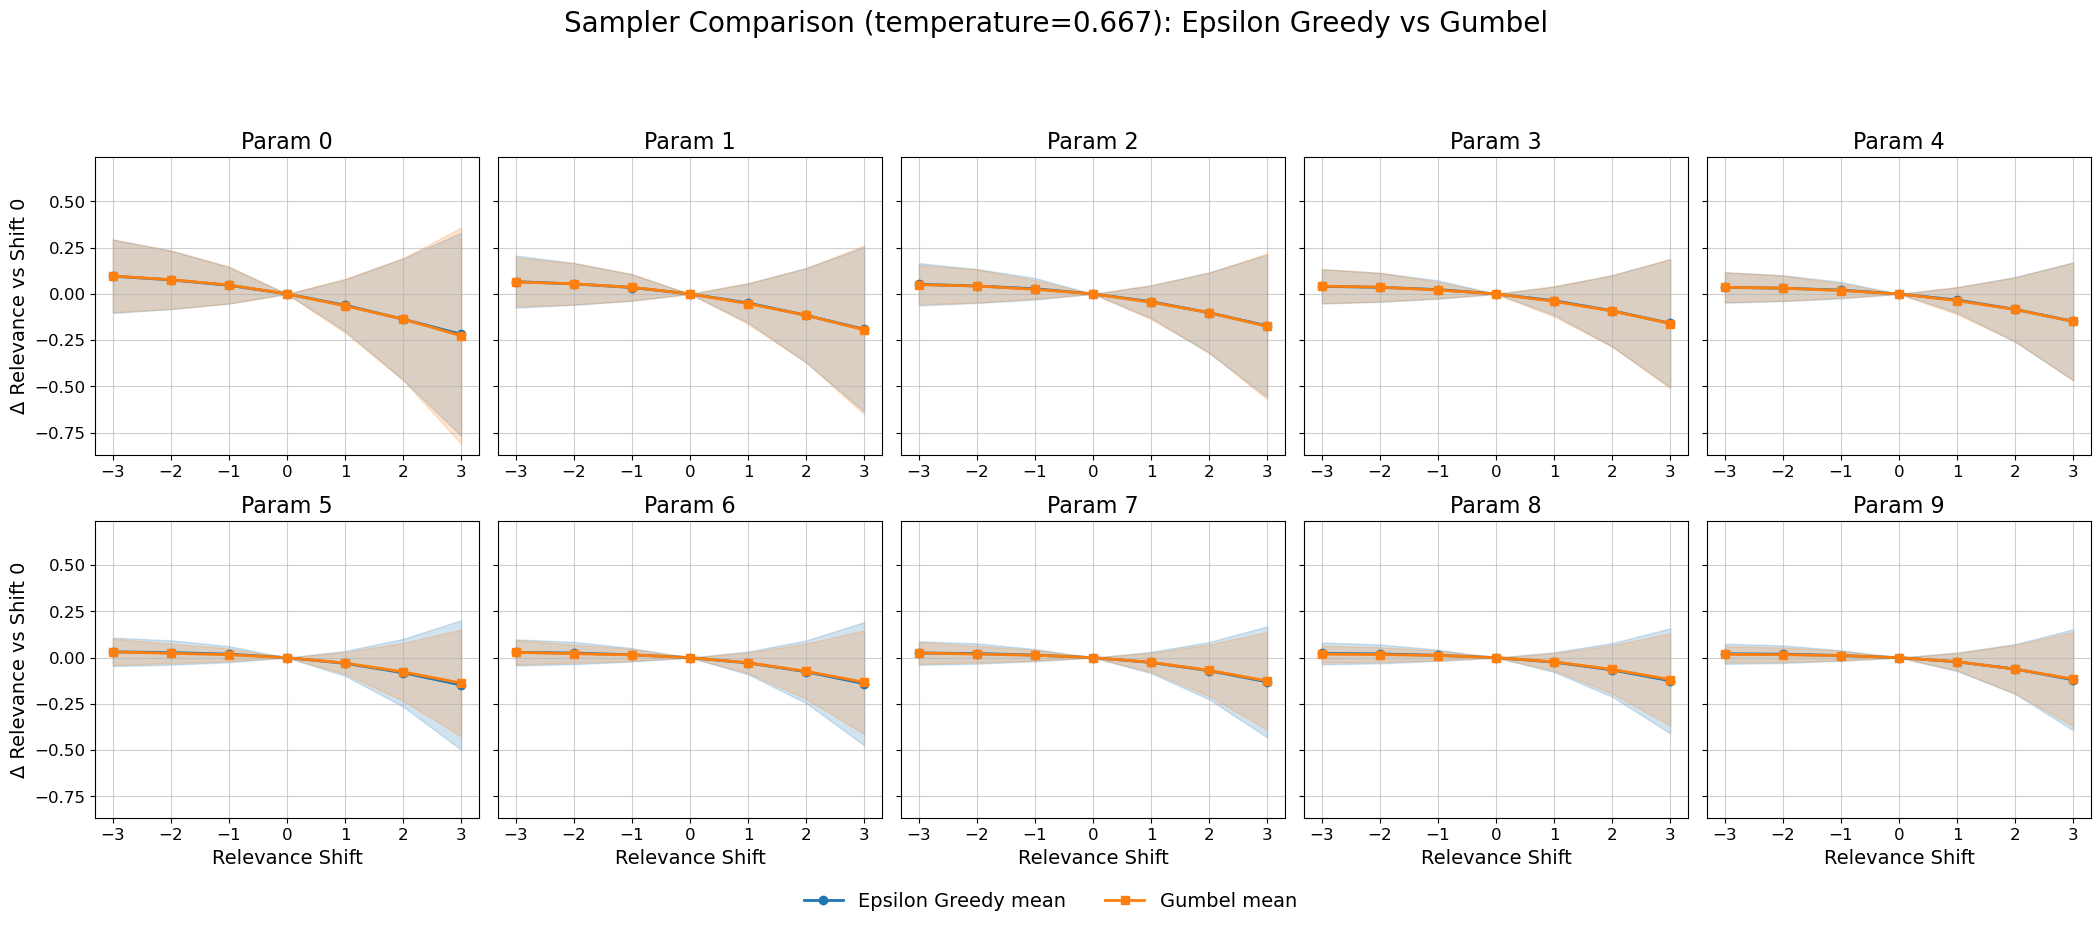

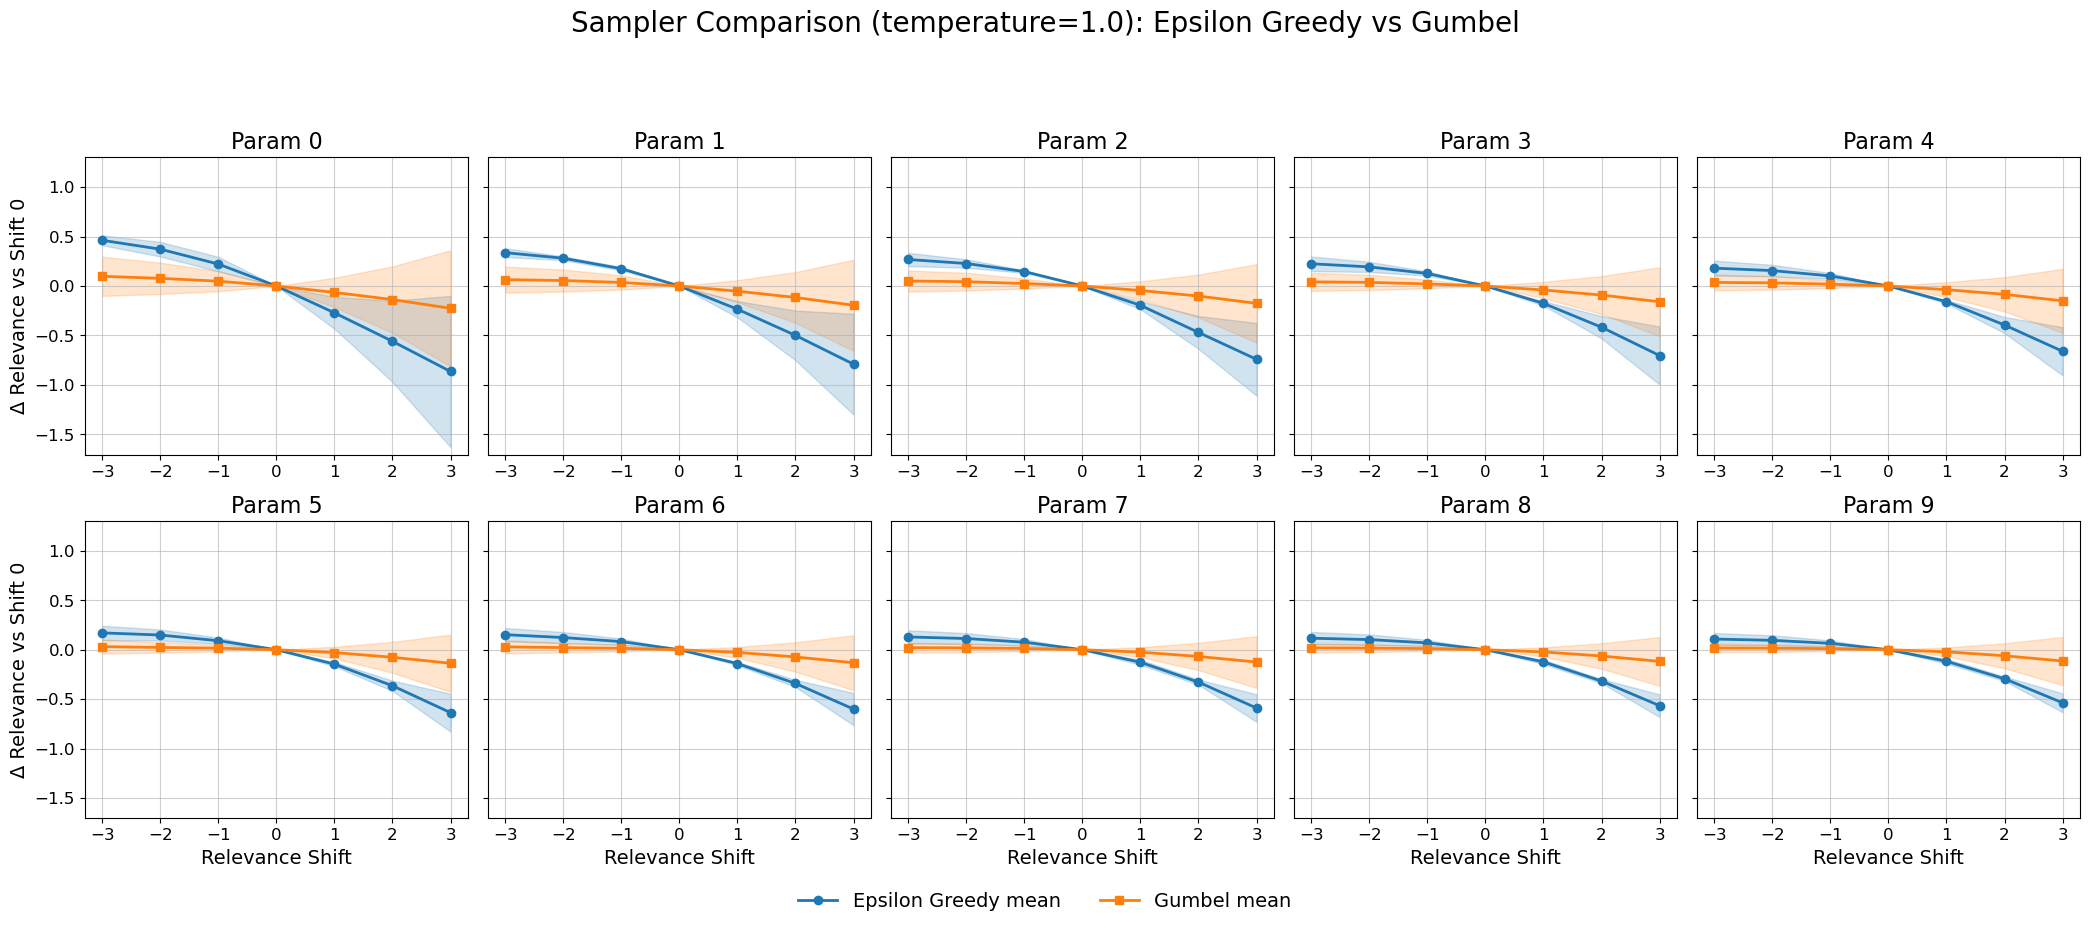

In [176]:

def plot_sampler_comparison(multi_relevance_df_a, multi_relevance_df_b, sampler_a, sampler_b, temperature):
    fig, axes = plt.subplots(2, 5, figsize=(21, 9), sharey=True)
    axes = axes.flatten()

    all_means = []
    all_stds = []

    for idx in range(10):
        ax = axes[idx]

        # --- Sampler A ---
        subset_a = multi_relevance_df_a[multi_relevance_df_a['param_idx'] == idx]
        baseline_a = subset_a[subset_a['relevance_shift'] == 0]['relevance'].reset_index(drop=True)
        diff_df_a = pd.DataFrame()
        for shift in sorted(subset_a['relevance_shift'].unique()):
            values = subset_a[subset_a['relevance_shift'] == shift]['relevance'].reset_index(drop=True)
            diff_df_a[shift] = values - baseline_a
        means_a, stds_a = diff_df_a.mean(), diff_df_a.std()

        # --- Sampler B ---
        subset_b = multi_relevance_df_b[multi_relevance_df_b['param_idx'] == idx]
        baseline_b = subset_b[subset_b['relevance_shift'] == 0]['relevance'].reset_index(drop=True)
        diff_df_b = pd.DataFrame()
        for shift in sorted(subset_b['relevance_shift'].unique()):
            values = subset_b[subset_b['relevance_shift'] == shift]['relevance'].reset_index(drop=True)
            diff_df_b[shift] = values - baseline_b
        means_b, stds_b = diff_df_b.mean(), diff_df_b.std()

        # Track ranges for global y-limits
        all_means.extend(means_a.values)
        all_means.extend(means_b.values)
        all_stds.extend(stds_a.values)
        all_stds.extend(stds_b.values)

        # --- Plot std bands first ---
        ax.fill_between(means_a.index, means_a - stds_a, means_a + stds_a, color='tab:blue', alpha=0.2)
        ax.fill_between(means_b.index, means_b - stds_b, means_b + stds_b, color='tab:orange', alpha=0.2)

        # --- Plot mean lines on top ---
        ax.plot(means_a.index, means_a.values, marker='o', color='tab:blue', label=f'{sampler_a} mean' if idx == 0 else "", linewidth=2)
        ax.plot(means_b.index, means_b.values, marker='s', color='tab:orange', label=f'{sampler_b} mean' if idx == 0 else "", linewidth=2)

        ax.set_title(f'Param {idx}', fontsize=16)
        ax.tick_params(axis='both', labelsize=12)
        ax.grid(True, alpha=0.6)

        if idx % 5 == 0:
            ax.set_ylabel('Δ Relevance vs Shift 0', fontsize=14)
        if idx >= 5:
            ax.set_xlabel('Relevance Shift', fontsize=14)

    # Adjust y-limits globally (10% margin)
    ymin = min(all_means) - max(all_stds) * 1.1
    ymax = max(all_means) + max(all_stds) * 1.1
    for ax in axes:
        ax.set_ylim(ymin, ymax)

    # Global title
    fig.suptitle(f'Sampler Comparison (temperature={temperature}): {sampler_a} vs {sampler_b}', fontsize=20, y=1.02)

    # Legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', fontsize=14, ncol=2, frameon=False)

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()


plot_sampler_comparison(
    multi_relevance_df_tmp_0333, multi_relevance_df_gumbel_0333,
    'Epsilon Greedy', 'Gumbel', 0.333
)

plot_sampler_comparison(
    multi_relevance_df_tmp_0667, multi_relevance_df_gumbel_0667,
    'Epsilon Greedy', 'Gumbel', 0.667
)

plot_sampler_comparison(
    multi_relevance_df_tmp_1, multi_relevance_df_gumbel_1,
    'Epsilon Greedy', 'Gumbel', 1.0
)


In [179]:
import altair as alt
import pandas as pd

from notebooks.utils import load
from two_tower_confounding.simulation.simulator import get_position_bias

In [180]:
def theme():
    return {
        "config": {
             "title": {
                "font": "serif",
                "fontWeight": "normal",
                "fontSize": 16,
                "dx": 5,
                 "subtitleFont": "serif",
                 "subtitleFontSize": 14,
            },
            "axis": {
                "titleFont": "serif",
                "titleFontWeight": "normal",
                "titleFontSize": 16,
                "labelFont": "serif",
                "labelFontWeight": "normal",
                "labelFontSize": 14
            },
            "headerColumn": {
                "titleFont": "serif",
                "titleFontWeight": "normal",
                "titleFontSize": 16,
                "labelFont": "serif",
                "labelFontWeight": "normal",
                "labelFontSize": 16
            },
            "text": {
                "font": "serif",
                "fontSize": 14,
            },
            "legend": {
                "symbolOpacity": 1,
                "titleFont": "serif",
                "titleFontWeight": "normal",
                "titleFontSize": 16,
                "labelFont": "serif",
                "labelFontWeight": "normal",
                "labelFontSize": 16,
            }
        },
    }

alt.themes.register("latex", theme)
alt.themes.enable("latex")

/var/folders/nb/j_h4xjxd1tl7g7169hm8cdnc0000gn/T/ipykernel_4160/782434750.py:44: AltairDeprecationWarning: 
Deprecated since `altair=5.5.0`. Use altair.theme instead.
Most cases require only the following change:

    # Deprecated
    alt.themes.enable('quartz')

    # Updated
    alt.theme.enable('quartz')

If your code registers a theme, make the following change:

    # Deprecated
    def custom_theme():
        return {'height': 400, 'width': 700}
    alt.themes.register('theme_name', custom_theme)
    alt.themes.enable('theme_name')

    # Updated
    @alt.theme.register('theme_name', enable=True)
    def custom_theme():
        return alt.theme.ThemeConfig(
            {'height': 400, 'width': 700}
        )

See the updated User Guide for further details:
    https://altair-viz.github.io/user_guide/api.html#theme
    https://altair-viz.github.io/user_guide/customization.html#chart-themes
  alt.themes.register("latex", theme)


ThemeRegistry.enable('latex')

In [202]:
def plot_bias(experiment, policy_strength, sampler, title="", subtitle="", width=225, height=125, color="blues", show_axis_title=True):
    scheme = {
        "blue": ["#C6DBEF", "#9ECAE1", "#6BAED6", "#3182BD", "#636363"],
        "green": ["#C7E9C0", "#A1D99B", "#74C476", "#31A354", "#636363"],
        "orange": ["#FDD0A2", "#FD8D3C", "#FD8D3C", "#E6550E", "#636363"],
    }[color]

    
    bias_df = load(experiment, "bias.csv")
    bias_df = bias_df[bias_df["policy_strength"] == policy_strength]

    bias_df = bias_df[bias_df["logging_policy_sampler"] != sampler]

    n_positions = bias_df.position.max() + 1
    true_bias_df = pd.DataFrame(
        {
            "position": range(n_positions),
            "examination": get_position_bias(n_positions, 1),
            "policy_temperature": "Simulated Bias"
        }
    )

    bias_df = pd.concat([bias_df, true_bias_df])
    bias_df["position"] += 1

    base = alt.Chart(bias_df, width=width, height=height, title=alt.Title(text=title, subtitle=subtitle)).encode(
        x=alt.X("position:Q", title="Position").axis(labelAngle=0, values=[1, 5, 10, 15, 20, 25]).scale(nice=False)
    )
    
    line = base.mark_line(point=True, opacity=1).encode(
        y=alt.Y("mean(examination):Q", title="Bias Logits" if show_axis_title else None),
        color=alt.Color("policy_temperature:O", title="Temperature 𝜏").scale(range=scheme)
    )
    
    ci = base.mark_errorband(extent="ci").encode(
        y=alt.Y("examination:Q", title="Bias Logits" if show_axis_title else None),
        color=alt.Color("policy_temperature:O").scale(range=scheme)
    )
    
    return ci + line, bias_df





linear, linear_bias_df = plot_bias("test_single_varying", policy_strength=1, sampler="gumbel", color="green", title="Epsilion Greedy Sampler, Linear Relevance Tower", subtitle="linear rel., policy strength 𝛼 = 1")
deep, deep_bias_df = plot_bias("test_single_varying", policy_strength=1, sampler="nan", color="green", title="Gumbel Max Sampler, Linear Relevance Tower", subtitle="linear rel., policy strength 𝛼 = 1", show_axis_title=False)


chart = (
    linear | deep
).configure_line(
    size=2
).configure_point(
    size=15
).resolve_scale(
    y="shared"
).configure_concat(
    spacing=5
)



chart

alt.HConcatChart(...)

['test_relevance_param_shift_1.0_idx1.csv', 'test_relevance_param_shift_-3.0_idx1.csv', 'test_relevance_param_shift_-3.0_idx0.csv', 'test_relevance_param_shift_1.0_idx0.csv', 'test_relevance_param_shift_1.0_idx2.csv', 'test_relevance_param_shift_-3.0_idx2.csv', 'test_relevance_param_shift_-3.0_idx3.csv', 'test_relevance_param_shift_1.0_idx3.csv', 'test_relevance_param_shift_-3.0_idx7.csv', 'test_relevance_param_shift_1.0_idx7.csv', 'test_relevance_param_shift_2.0_idx9.csv', 'test_relevance_param_shift_2.0_idx8.csv', 'test_relevance_param_shift_1.0_idx6.csv', 'test_relevance_param_shift_-3.0_idx6.csv', 'test_relevance_param_shift_-3.0_idx4.csv', 'test_relevance_param_shift_1.0_idx4.csv', 'test_relevance_param_shift_1.0_idx5.csv', 'test_relevance_param_shift_-3.0_idx5.csv', 'test_relevance_param_shift_3.0_idx0.csv', 'test_relevance_param_shift_-1.0_idx0.csv', 'test_relevance_param_shift_-1.0_idx1.csv', 'test_relevance_param_shift_3.0_idx1.csv', 'test_relevance_param_shift_3.0_idx3.csv', 

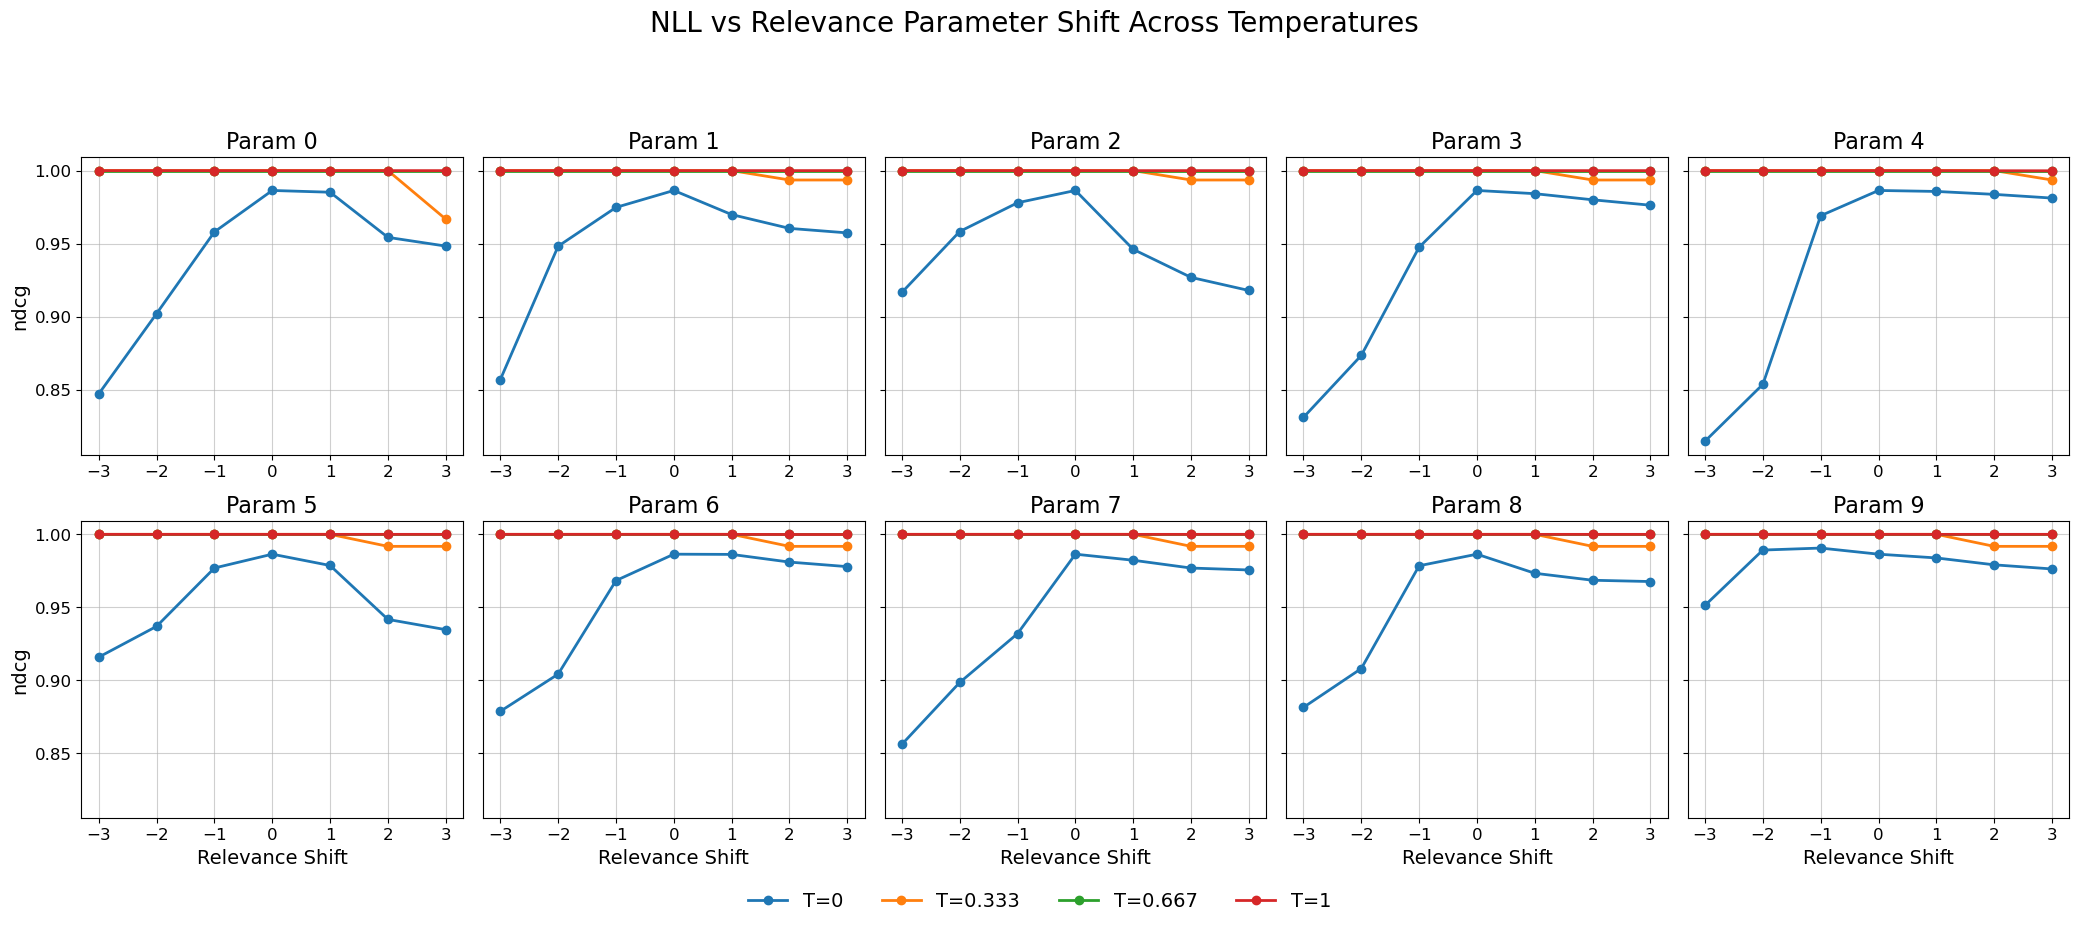

['test_clicks_param_shift_0.0_idx2.csv', 'test_clicks_param_shift_-2.0_idx8.csv', 'test_clicks_param_shift_-1.0_idx6.csv', 'test_clicks_param_shift_-1.0_idx7.csv', 'test_clicks_param_shift_-2.0_idx9.csv', 'test_clicks_param_shift_0.0_idx3.csv', 'test_clicks_param_shift_0.0_idx1.csv', 'test_clicks_param_shift_-1.0_idx5.csv', 'test_clicks_param_shift_-1.0_idx4.csv', 'test_clicks_param_shift_0.0_idx0.csv', 'test_clicks_param_shift_0.0_idx4.csv', 'test_clicks_param_shift_-1.0_idx0.csv', 'test_clicks_param_shift_-1.0_idx1.csv', 'test_clicks_param_shift_0.0_idx5.csv', 'test_clicks_param_shift_0.0_idx7.csv', 'test_clicks_param_shift_3.0_idx9.csv', 'test_clicks_param_shift_-1.0_idx3.csv', 'test_clicks_param_shift_-1.0_idx2.csv', 'test_clicks_param_shift_3.0_idx8.csv', 'test_clicks_param_shift_0.0_idx6.csv', 'test_clicks_param_shift_-3.0_idx7.csv', 'test_clicks_param_shift_2.0_idx3.csv', 'test_clicks_param_shift_2.0_idx2.csv', 'test_clicks_param_shift_-3.0_idx6.csv', 'test_clicks_param_shift_-3

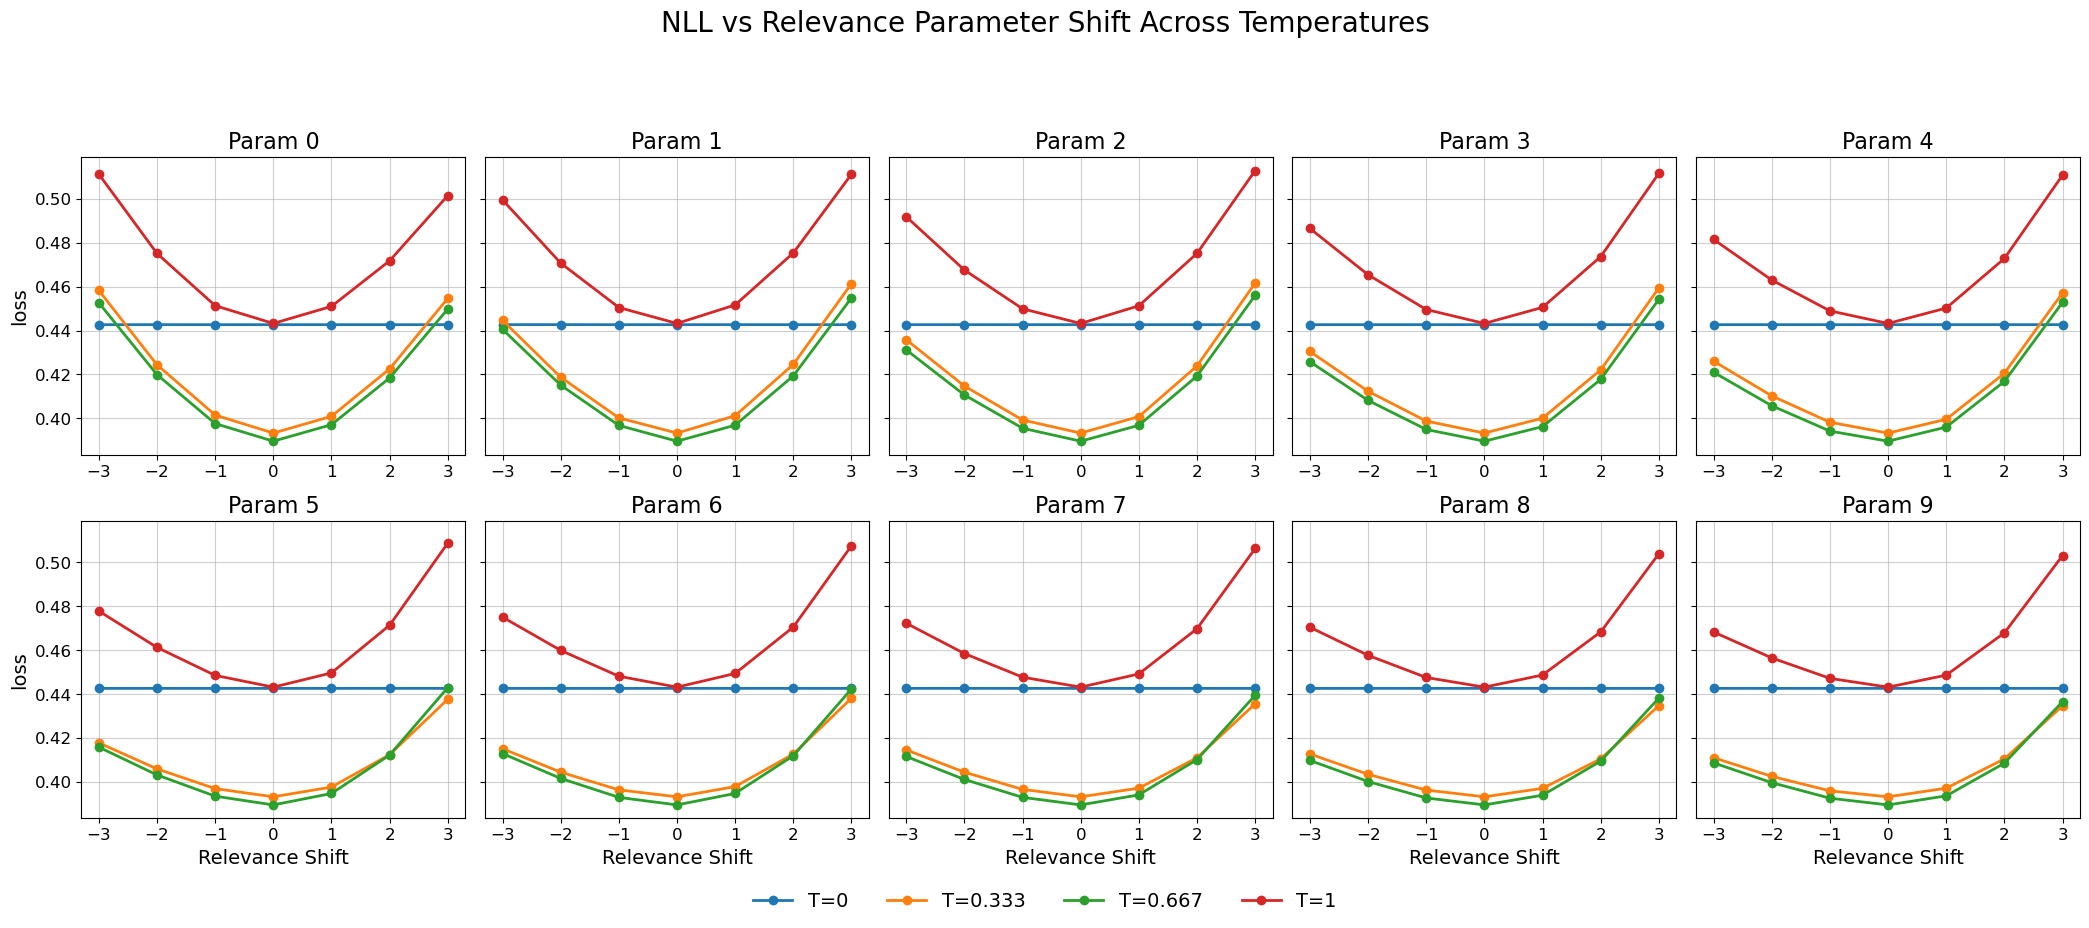

In [203]:
def plot_performance_grid_all_temps(multi_performance_dfs, temperatures, metric='ndcg@10'):
    """
    Plot NLL vs Relevance Shift for each param_idx (5x2 grid),
    overlaying results for multiple temperatures.

    Args:
        multi_performance_dfs (list): list of DataFrames, one per temperature
        temperatures (list): list of temperature values (same order as dfs)
    """
    fig, axes = plt.subplots(2, 5, figsize=(21, 9), sharey=True)
    axes = axes.flatten()

    for idx in range(10):
        ax = axes[idx]
        for df, temp in zip(multi_performance_dfs, temperatures):
            subset = df[df['param_idx'] == idx]
            ax.plot(subset['relevance_shift'], subset[metric], marker='o', linewidth=2, label=f'T={temp}')

        ax.set_title(f'Param {idx}', fontsize=16)
        ax.tick_params(axis='both', labelsize=12)
        ax.grid(True, alpha=0.6)

        if idx % 5 == 0:  # first column
            ax.set_ylabel(metric, fontsize=14)
        if idx >= 5:  # bottom row
            ax.set_xlabel('Relevance Shift', fontsize=14)

    # Global title
    fig.suptitle('NLL vs Relevance Parameter Shift Across Temperatures',
                 fontsize=20, y=1.02)

    # Shared legend below
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', fontsize=14, ncol=len(temperatures), frameon=False)

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()


prefix_performance_clicks = 'test_clicks_param_shift_'
prefix_performance_relevance = 'test_relevance_param_shift_'


multi_performance_df_tmp_0 = load_and_concat_multi_shift_files(folder_path_tmp_0, prefix_performance_relevance, 'relevance_shift', 'param_idx')
multi_performance_df_tmp_0333 = load_and_concat_multi_shift_files(folder_path_tmp_0333, prefix_performance_relevance, 'relevance_shift', 'param_idx')
multi_performance_df_tmp_0667 = load_and_concat_multi_shift_files(folder_path_tmp_0667, prefix_performance_relevance, 'relevance_shift', 'param_idx')
multi_performance_df_tmp_1 = load_and_concat_multi_shift_files(folder_path_tmp_1, prefix_performance_relevance, 'relevance_shift', 'param_idx')

plot_performance_grid_all_temps(
    [multi_performance_df_tmp_0,
     multi_performance_df_tmp_0333,
     multi_performance_df_tmp_0667,
     multi_performance_df_tmp_1],
    [0, 0.333, 0.667, 1],
    metric='ndcg'
)

multi_performance_df_tmp_0 = load_and_concat_multi_shift_files(folder_path_tmp_0, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_tmp_0333 = load_and_concat_multi_shift_files(folder_path_tmp_0333, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_tmp_0667 = load_and_concat_multi_shift_files(folder_path_tmp_0667, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_tmp_1 = load_and_concat_multi_shift_files(folder_path_tmp_1, prefix_performance_clicks , 'relevance_shift', 'param_idx')

plot_performance_grid_all_temps(
    [multi_performance_df_tmp_0,
     multi_performance_df_tmp_0333,
     multi_performance_df_tmp_0667, 
     multi_performance_df_tmp_1],
    [0, 0.333, 0.667, 1],
    metric='loss'
)